# PeMS 5分钟交通流数据整理 - 车道级版本

## 功能特点

1. **保留车道级数据**：每个车道的流量、占有率、速度
2. **宽表转长表**：将 Lane1_Flow, Lane2_Flow... 转换为 (Lane, Flow) 格式
3. **支持多种输出格式**：
   - 站点级汇总（总流量）
   - 车道级明细（每车道数据）
   - 原始宽表格式

---
# Part 1: 数据合并与保存
---

## 1.1 环境配置

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

print("库加载完成！")
print(f"Pandas 版本: {pd.__version__}")

库加载完成！
Pandas 版本: 2.3.3


## 1.2 配置路径

In [2]:
# ============== 配置区域 ==============
# 原始数据文件夹
RAW_FOLDER = "/data/yuzhang_fei/PEMS/PEMSD3_2025"  # 修改为你的路径

# 输出目录
PROCESSED_FOLDER = "/data/yuzhang_fei/PEMS/processed_data/PEMSD3_2025"
OUTPUT_DIR = "../output/lane_level"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PROCESSED_FOLDER, exist_ok=True)

# 输出文件路径
OUTPUT_STATION_LEVEL = os.path.join(PROCESSED_FOLDER, 'pems_5min_station_level.parquet')  # 站点级
OUTPUT_LANE_LEVEL = os.path.join(PROCESSED_FOLDER, 'pems_5min_lane_level.parquet')        # 车道级
OUTPUT_WIDE_FORMAT = os.path.join(PROCESSED_FOLDER, 'pems_5min_wide_format.parquet')      # 宽表格式

# 查看文件列表
txt_files = sorted(glob.glob(os.path.join(RAW_FOLDER, "*.txt")))
print(f"找到 {len(txt_files)} 个数据文件")
print(f"原始数据文件夹: {RAW_FOLDER}")
print(f"处理后数据输出目录: {PROCESSED_FOLDER}")
print(f"输出目录: {OUTPUT_DIR}")


找到 363 个数据文件
原始数据文件夹: /data/yuzhang_fei/PEMS/PEMSD3_2025
处理后数据输出目录: /data/yuzhang_fei/PEMS/processed_data/PEMSD3_2025
输出目录: ../output/lane_level


## 1.3 定义字段结构

In [3]:
MAX_LANES = 8

# 基础字段（站点级）
BASE_COLUMNS = [
    'Timestamp', 'Station', 'District', 'Freeway', 'Direction',
    'Lane_Type', 'Station_Length', 'Samples', 'Pct_Observed',
    'Total_Flow', 'Avg_Occupancy', 'Avg_Speed'
]

# 车道字段（每车道5个字段）
LANE_COLUMNS = []
for i in range(1, MAX_LANES + 1):
    LANE_COLUMNS.extend([
        f'Lane{i}_Samples', 
        f'Lane{i}_Flow', 
        f'Lane{i}_Avg_Occ',
        f'Lane{i}_Avg_Speed', 
        f'Lane{i}_Observed'
    ])

ALL_COLUMNS = BASE_COLUMNS + LANE_COLUMNS

print(f"基础字段数: {len(BASE_COLUMNS)}")
print(f"车道字段数: {len(LANE_COLUMNS)} ({MAX_LANES} 车道 × 5 字段)")
print(f"总字段数: {len(ALL_COLUMNS)}")
print(f"\n车道字段示例: {LANE_COLUMNS[:5]}")

基础字段数: 12
车道字段数: 40 (8 车道 × 5 字段)
总字段数: 52

车道字段示例: ['Lane1_Samples', 'Lane1_Flow', 'Lane1_Avg_Occ', 'Lane1_Avg_Speed', 'Lane1_Observed']


## 1.4 数据加载函数

In [4]:
def load_single_file(file_path, columns):
    """
    加载单个数据文件
    """
    df = pd.read_csv(
        file_path, 
        header=None, 
        names=columns, 
        dtype={'Station': str},
        low_memory=False
    )
    return df


def convert_wide_to_lane_level(df_wide, max_lanes=8):
    """
    将宽表格式转换为车道级长表格式
    
    宽表: Station, Timestamp, Lane1_Flow, Lane2_Flow, ...
    长表: Station, Timestamp, Lane, Flow, Occ, Speed, ...
    """
    # 基础列（保留）
    id_cols = ['Timestamp', 'Station', 'District', 'Freeway', 'Direction', 
               'Lane_Type', 'Station_Length', 'Samples', 'Pct_Observed',
               'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']
    
    lane_records = []
    
    for lane_num in range(1, max_lanes + 1):
        # 获取该车道的列
        lane_cols = {
            f'Lane{lane_num}_Samples': 'Lane_Samples',
            f'Lane{lane_num}_Flow': 'Lane_Flow',
            f'Lane{lane_num}_Avg_Occ': 'Lane_Occ',
            f'Lane{lane_num}_Avg_Speed': 'Lane_Speed',
            f'Lane{lane_num}_Observed': 'Lane_Observed'
        }
        
        # 检查列是否存在
        existing_cols = [c for c in lane_cols.keys() if c in df_wide.columns]
        if not existing_cols:
            continue
        
        # 提取该车道数据
        lane_df = df_wide[id_cols + existing_cols].copy()
        lane_df = lane_df.rename(columns=lane_cols)
        lane_df['Lane'] = lane_num
        
        # 只保留有数据的车道（Flow 不全为 NaN 或 0）
        if 'Lane_Flow' in lane_df.columns:
            valid_mask = lane_df['Lane_Flow'].notna() & (lane_df['Lane_Flow'] > 0)
            if valid_mask.any():
                lane_records.append(lane_df[valid_mask])
    
    if lane_records:
        return pd.concat(lane_records, ignore_index=True)
    else:
        return pd.DataFrame()


print("函数定义完成！")

函数定义完成！


## 1.5 合并数据（三种格式）

In [5]:
def merge_all_files(file_list, columns, output_dir, 
                    save_station_level=True,
                    save_lane_level=True,
                    save_wide_format=False,
                    batch_size=30):
    """
    合并所有文件并保存为不同格式
    
    参数:
    - save_station_level: 保存站点级汇总（总流量）
    - save_lane_level: 保存车道级明细
    - save_wide_format: 保存原始宽表格式
    - batch_size: 每批处理的文件数（避免内存溢出）
    """
    total_files = len(file_list)
    
    # 站点级数据（核心字段）
    station_cols = ['Timestamp', 'Station', 'Samples', 'Pct_Observed',
                    'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']
    
    station_dfs = []
    lane_dfs = []
    wide_dfs = []
    
    print(f"开始处理 {total_files} 个文件...")
    print(f"保存格式: 站点级={save_station_level}, 车道级={save_lane_level}, 宽表={save_wide_format}")
    print("=" * 60)
    
    for i, f in enumerate(file_list):
        try:
            # 加载原始数据
            df = load_single_file(f, columns)
            
            # 1. 站点级数据
            if save_station_level:
                station_dfs.append(df[station_cols].copy())
            
            # 2. 车道级数据
            if save_lane_level:
                lane_df = convert_wide_to_lane_level(df)
                if len(lane_df) > 0:
                    lane_dfs.append(lane_df)
            
            # 3. 宽表格式
            if save_wide_format:
                wide_dfs.append(df)
            
        except Exception as e:
            print(f"读取失败 {os.path.basename(f)}: {e}")
        
        # 进度显示
        if (i + 1) % 10 == 0:
            print(f"已处理 {i + 1}/{total_files} ({(i+1)/total_files*100:.1f}%)")
        
        # 定期保存（避免内存溢出）
        if (i + 1) % batch_size == 0 and i + 1 < total_files:
            print(f"  [批次 {(i+1)//batch_size}] 清理内存...")
            # 可以在这里添加中间保存逻辑
    
    print("\n" + "=" * 60)
    print("合并数据...")
    
    results = {}
    
    # 合并站点级数据
    if save_station_level and station_dfs:
        print("\n[1/3] 合并站点级数据...")
        station_combined = pd.concat(station_dfs, ignore_index=True)
        station_combined['Timestamp'] = pd.to_datetime(station_combined['Timestamp'], 
                                                        format='%m/%d/%Y %H:%M:%S')
        for col in ['Samples', 'Pct_Observed', 'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']:
            station_combined[col] = pd.to_numeric(station_combined[col], errors='coerce')
        
        output_path = os.path.join(output_dir, 'pems_5min_station_level.parquet')
        station_combined.to_parquet(output_path, index=False)
        print(f"  保存: {output_path}")
        print(f"  行数: {len(station_combined):,}")
        print(f"  大小: {os.path.getsize(output_path)/1024/1024:.2f} MB")
        results['station'] = station_combined
        del station_dfs
    
    # 合并车道级数据
    if save_lane_level and lane_dfs:
        print("\n[2/3] 合并车道级数据...")
        lane_combined = pd.concat(lane_dfs, ignore_index=True)
        lane_combined['Timestamp'] = pd.to_datetime(lane_combined['Timestamp'], 
                                                     format='%m/%d/%Y %H:%M:%S')
        # 转换数值列
        numeric_cols = ['Lane_Samples', 'Lane_Flow', 'Lane_Occ', 'Lane_Speed', 'Lane_Observed',
                        'Total_Flow', 'Avg_Occupancy', 'Avg_Speed']
        for col in numeric_cols:
            if col in lane_combined.columns:
                lane_combined[col] = pd.to_numeric(lane_combined[col], errors='coerce')
        
        output_path = os.path.join(output_dir, 'pems_5min_lane_level.parquet')
        lane_combined.to_parquet(output_path, index=False)
        print(f"  保存: {output_path}")
        print(f"  行数: {len(lane_combined):,}")
        print(f"  大小: {os.path.getsize(output_path)/1024/1024:.2f} MB")
        results['lane'] = lane_combined
        del lane_dfs
    
    # 合并宽表数据
    if save_wide_format and wide_dfs:
        print("\n[3/3] 合并宽表数据...")
        wide_combined = pd.concat(wide_dfs, ignore_index=True)
        wide_combined['Timestamp'] = pd.to_datetime(wide_combined['Timestamp'], 
                                                     format='%m/%d/%Y %H:%M:%S')
        
        output_path = os.path.join(output_dir, 'pems_5min_wide_format.parquet')
        wide_combined.to_parquet(output_path, index=False)
        print(f"  保存: {output_path}")
        print(f"  行数: {len(wide_combined):,}")
        print(f"  大小: {os.path.getsize(output_path)/1024/1024:.2f} MB")
        results['wide'] = wide_combined
        del wide_dfs
    
    print("\n" + "=" * 60)
    print("✓ 数据处理完成！")
    
    return results

In [6]:
# ============== 执行合并 ==============
# 可以根据需要选择保存哪些格式

results = merge_all_files(
    txt_files, 
    ALL_COLUMNS, 
    PROCESSED_FOLDER,
    save_station_level=True,   # 站点级汇总
    save_lane_level=True,      # 车道级明细 ← 新增
    save_wide_format=False,    # 原始宽表（占用空间大）
    batch_size=50
)

开始处理 363 个文件...
保存格式: 站点级=True, 车道级=True, 宽表=False
已处理 10/363 (2.8%)
已处理 20/363 (5.5%)
已处理 30/363 (8.3%)
已处理 40/363 (11.0%)
已处理 50/363 (13.8%)
  [批次 1] 清理内存...
已处理 60/363 (16.5%)
已处理 70/363 (19.3%)
已处理 80/363 (22.0%)
已处理 90/363 (24.8%)
已处理 100/363 (27.5%)
  [批次 2] 清理内存...
已处理 110/363 (30.3%)
已处理 120/363 (33.1%)
已处理 130/363 (35.8%)
已处理 140/363 (38.6%)
已处理 150/363 (41.3%)
  [批次 3] 清理内存...
已处理 160/363 (44.1%)
已处理 170/363 (46.8%)
已处理 180/363 (49.6%)
已处理 190/363 (52.3%)
已处理 200/363 (55.1%)
  [批次 4] 清理内存...
已处理 210/363 (57.9%)
已处理 220/363 (60.6%)
已处理 230/363 (63.4%)
已处理 240/363 (66.1%)
已处理 250/363 (68.9%)
  [批次 5] 清理内存...
已处理 260/363 (71.6%)
已处理 270/363 (74.4%)
已处理 280/363 (77.1%)
已处理 290/363 (79.9%)
已处理 300/363 (82.6%)
  [批次 6] 清理内存...
已处理 310/363 (85.4%)
已处理 320/363 (88.2%)
已处理 330/363 (90.9%)
已处理 340/363 (93.7%)
已处理 350/363 (96.4%)
  [批次 7] 清理内存...
已处理 360/363 (99.2%)

合并数据...

[1/3] 合并站点级数据...
  保存: /data/yuzhang_fei/PEMS/processed_data/PEMSD3_2025/pems_5min_station_level.parquet
  行数: 1

---
# Part 2: 车道级数据分析
---

## 2.1 加载车道级数据

In [4]:
# 加载已保存的车道级数据
LANE_DATA_PATH = os.path.join(PROCESSED_FOLDER, 'pems_5min_lane_level.parquet')

if os.path.exists(LANE_DATA_PATH):
    print(f"加载车道级数据: {LANE_DATA_PATH}")
    lane_df = pd.read_parquet(LANE_DATA_PATH)
    print(f"数据形状: {lane_df.shape}")
    print(f"\n列名: {lane_df.columns.tolist()}")
else:
    print(f"文件不存在: {LANE_DATA_PATH}")
    print("请先运行 Part 1 生成数据")

加载车道级数据: /data/yuzhang_fei/PEMS/processed_data/PEMSD3_2025/pems_5min_lane_level.parquet
数据形状: (332214772, 18)

列名: ['Timestamp', 'Station', 'District', 'Freeway', 'Direction', 'Lane_Type', 'Station_Length', 'Samples', 'Pct_Observed', 'Total_Flow', 'Avg_Occupancy', 'Avg_Speed', 'Lane_Samples', 'Lane_Flow', 'Lane_Occ', 'Lane_Speed', 'Lane_Observed', 'Lane']


In [5]:
# 查看数据示例
if 'lane_df' in dir():
    print("车道级数据示例:")
    display(lane_df.head(10))

车道级数据示例:


,Timestamp,Station,District,Freeway,Direction,Lane_Type,Station_Length,Samples,Pct_Observed,Total_Flow,Avg_Occupancy,Avg_Speed,Lane_Samples,Lane_Flow,Lane_Occ,Lane_Speed,Lane_Observed,Lane
0,2025-01-01,308512,3,50,W,ML,3.995,17,0,44.0,0.0272,63.7,8.0,19.0,0.0243,66.2,0,1
1,2025-01-01,311832,3,5,S,FR,NaN,10,100,3.0,NaN,NaN,10.0,3.0,NaN,NaN,1,1
2,2025-01-01,311844,3,5,N,OR,NaN,20,100,6.0,NaN,NaN,10.0,4.0,NaN,NaN,1,1
3,2025-01-01,311903,3,50,E,ML,0.883,27,33,55.0,0.0170,65.1,9.0,9.0,0.0039,66.0,0,1
4,2025-01-01,311930,3,50,E,FF,NaN,27,100,51.0,0.0132,NaN,9.0,6.0,0.0029,NaN,1,1
5,2025-01-01,311973,3,50,E,OR,NaN,10,100,2.0,NaN,NaN,10.0,2.0,NaN,NaN,1,1
6,2025-01-01,311974,3,50,E,ML,0.466,50,0,200.0,0.0418,60.3,10.0,17.0,0.0180,69.3,0,1
7,2025-01-01,312010,3,50,W,ML,0.752,0,0,104.0,0.0177,70.8,0.0,23.0,0.0142,75.3,0,1
8,2025-01-01,312103,3,50,W,ML,1.157,0,0,98.0,0.0205,68.7,0.0,20.0,0.0145,74.5,0,1
9,2025-01-01,312132,3,5,S,ML,1.347,20,100,30.0,0.0197,67.7,10.0,13.0,0.0086,71.2,1,1


In [6]:
# 基本统计
if 'lane_df' in dir():
    print("=" * 60)
    print("车道级数据统计")
    print("=" * 60)
    print(f"总记录数: {len(lane_df):,}")
    print(f"站点数: {lane_df['Station'].nunique():,}")
    print(f"车道分布:")
    print(lane_df['Lane'].value_counts().sort_index())
    print(f"\n日期范围: {lane_df['Timestamp'].min()} ~ {lane_df['Timestamp'].max()}")

车道级数据统计
总记录数: 332,214,772
站点数: 1,871
车道分布:
Lane
1    160578526
2     98157502
3     47056229
4     21243216
5      4814822
6       364477
Name: count, dtype: int64

日期范围: 2025-01-01 00:00:00 ~ 2025-12-31 23:55:00


## 2.2 车道级数据质量分析

In [7]:
if 'lane_df' in dir():
    # 各车道数据量统计
    lane_stats = lane_df.groupby('Lane').agg({
        'Station': 'nunique',
        'Lane_Flow': ['count', 'mean', 'std', 'min', 'max'],
        'Lane_Speed': ['mean', 'std'],
        'Lane_Occ': ['mean', 'std']
    }).round(2)
    
    lane_stats.columns = ['_'.join(col).strip() for col in lane_stats.columns.values]
    
    print("各车道统计:")
    display(lane_stats)

各车道统计:


,Station_nunique,Lane_Flow_count,Lane_Flow_mean,Lane_Flow_std,Lane_Flow_min,Lane_Flow_max,Lane_Speed_mean,Lane_Speed_std,Lane_Occ_mean,Lane_Occ_std
Lane,,,,,,,,,,
1,1838,160578526,43.09,42.46,1.0,450.0,66.98,7.99,0.04,0.04
2,1028,98157502,48.24,39.13,1.0,415.0,63.55,8.33,0.05,0.05
3,483,47056229,52.26,37.53,1.0,440.0,60.87,8.31,0.05,0.05
4,215,21243216,53.35,38.01,1.0,365.0,60.52,8.04,0.05,0.05
5,52,4814822,40.95,31.59,1.0,250.0,60.94,7.57,0.04,0.04
6,5,364477,55.70,42.17,1.0,210.0,60.23,10.50,0.05,0.05


In [11]:
if 'lane_df' in dir():
    # 每个站点的车道数分布
    lanes_per_station = lane_df.groupby(['Station', 'Timestamp'])['Lane'].nunique().reset_index()
    lanes_per_station.columns = ['Station', 'Timestamp', 'Num_Lanes']
    
    # 统计每个站点的典型车道数
    station_lane_count = lanes_per_station.groupby('Station')['Num_Lanes'].agg(['mean', 'min', 'max']).round(1)
    
    print("站点车道数分布:")
    print(station_lane_count['mean'].value_counts().sort_index())

站点车道数分布:
mean
1.0    861
1.1      2
1.2      3
1.3      9
1.4      6
1.5     14
1.6     15
1.7     21
1.8     42
1.9    141
2.0    288
2.1      2
2.2      3
2.3      2
2.4      2
2.5      1
2.6      7
2.7      7
2.8     13
2.9     37
3.0    182
3.2      1
3.5      2
3.6      2
3.7      2
3.8     12
3.9     16
4.0    129
4.5      2
4.7      5
4.8      2
4.9      4
5.0     32
5.9      1
6.0      3
Name: count, dtype: int64


## 2.3 加载多时间点元数据

In [8]:
# ============== 元数据配置 ==============
# 元数据文件夹（包含多个时间点的 d03_text_meta_YYYY_MM_DD.txt）
META_FOLDER = "../d03_meta"  # 修改为你的路径

import re

def parse_meta_date(filename):
    """从文件名解析日期"""
    match = re.search(r'(\d{4})_(\d{2})_(\d{2})', os.path.basename(filename))
    if match:
        return datetime(int(match.group(1)), int(match.group(2)), int(match.group(3)))
    return None

def load_metadata_file(file_path):
    """加载单个元数据文件"""
    columns = [
        'ID', 'Fwy', 'Dir', 'District', 'County', 'City', 
        'State_PM', 'Abs_PM', 'Latitude', 'Longitude', 'Length',
        'Type', 'Lanes', 'Name', 'User_ID_1', 'User_ID_2', 
        'User_ID_3', 'User_ID_4'
    ]
    df = pd.read_csv(file_path, sep='\t', names=columns, header=0,
                     dtype={'ID': str, 'Fwy': str, 'Dir': str, 'Type': str})
    return df

# 扫描元数据文件
meta_files = sorted(glob.glob(os.path.join(META_FOLDER, "d*_text_meta_*.txt")))
print(f"找到 {len(meta_files)} 个元数据文件")

# 建立日期索引
meta_by_date = {}
for f in meta_files:
    date = parse_meta_date(f)
    if date:
        meta_by_date[date] = f

print(f"日期范围: {min(meta_by_date.keys()).date()} ~ {max(meta_by_date.keys()).date()}")

找到 36 个元数据文件
日期范围: 2024-11-27 ~ 2025-12-30


In [9]:
def get_metadata_for_date(target_date, meta_by_date):
    """
    获取指定日期应使用的元数据
    
    逻辑：使用 <= target_date 的最新元数据文件
    （因为元数据在某个日期发布后，对该日期及之后的数据有效）
    """
    if isinstance(target_date, str):
        target_date = pd.to_datetime(target_date)
    if hasattr(target_date, 'date'):
        target_date = datetime.combine(target_date.date(), datetime.min.time())
    
    # 找到 <= target_date 的最新元数据
    valid_dates = [d for d in meta_by_date.keys() if d <= target_date]
    
    if not valid_dates:
        # 如果没有更早的，使用最早的元数据
        return min(meta_by_date.keys())
    
    return max(valid_dates)

# 测试
test_date = datetime(2025, 3, 15)
matched_meta_date = get_metadata_for_date(test_date, meta_by_date)
print(f"数据日期 {test_date.date()} → 使用元数据 {matched_meta_date.date()}")

数据日期 2025-03-15 → 使用元数据 2025-03-01


## 2.4 基于时间点的同位置传感器检测

In [10]:
def find_colocated_sensors(meta_df, pm_threshold=0.01):
    """
    找出同位置的传感器组（Fwy + Dir + Abs_PM 相同）
    这些通常是 HOV 车道和主线车道的分开检测器
    """
    colocated_groups = []
    
    for (fwy, direction), group in meta_df.groupby(['Fwy', 'Dir']):
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        i = 0
        while i < len(sorted_group):
            current_pm = sorted_group.iloc[i]['Abs_PM']
            
            # 找出同位置的所有传感器
            same_loc_mask = abs(sorted_group['Abs_PM'] - current_pm) < pm_threshold
            same_loc = sorted_group[same_loc_mask]
            
            if len(same_loc) > 1:
                colocated_groups.append({
                    'Fwy': fwy,
                    'Dir': direction,
                    'Abs_PM': current_pm,
                    'Sensor_Count': len(same_loc),
                    'IDs': same_loc['ID'].tolist(),
                    'Types': same_loc['Type'].tolist() if 'Type' in same_loc.columns else [],
                    'Lanes': same_loc['Lanes'].tolist(),
                    'Total_Lanes': same_loc['Lanes'].sum(),
                    'Names': same_loc['Name'].tolist() if 'Name' in same_loc.columns else []
                })
            
            i += len(same_loc)
    
    return pd.DataFrame(colocated_groups)


def build_colocated_mapping_by_period(meta_by_date, pm_threshold=0.01):
    """
    为每个元数据时间段构建同位置传感器映射
    
    返回:
    - period_mappings: {meta_date: {sensor_id: merged_id, ...}}
    - period_info: {meta_date: colocated_df}
    """
    period_mappings = {}
    period_info = {}
    
    sorted_dates = sorted(meta_by_date.keys())
    
    for meta_date in sorted_dates:
        meta_file = meta_by_date[meta_date]
        meta_df = load_metadata_file(meta_file)
        
        # 检测同位置传感器
        colocated_df = find_colocated_sensors(meta_df, pm_threshold)
        period_info[meta_date] = colocated_df
        
        # 构建映射
        id_to_merged = {}
        if len(colocated_df) > 0:
            for _, row in colocated_df.iterrows():
                merged_id = '+'.join(sorted(row['IDs']))
                for sensor_id in row['IDs']:
                    id_to_merged[sensor_id] = merged_id
        
        period_mappings[meta_date] = id_to_merged
    
    print(f"构建了 {len(period_mappings)} 个时间段的映射")
    
    # 统计变化
    for i, date in enumerate(sorted_dates):
        n_groups = len(period_info[date])
        n_sensors = len(period_mappings[date])
        
        if i > 0:
            prev_date = sorted_dates[i-1]
            prev_mapping = period_mappings[prev_date]
            curr_mapping = period_mappings[date]
            
            # 检测变化
            changed = sum(1 for k in set(prev_mapping) | set(curr_mapping)
                         if prev_mapping.get(k) != curr_mapping.get(k))
            if changed > 0:
                print(f"  {date.date()}: {n_groups} 组, {n_sensors} 传感器 (变化: {changed})")
        else:
            print(f"  {date.date()}: {n_groups} 组, {n_sensors} 传感器 (初始)")
    
    return period_mappings, period_info


# 构建所有时间段的映射
print("构建各时间段的同位置传感器映射...")
print("=" * 60)
period_mappings, period_info = build_colocated_mapping_by_period(meta_by_date)

构建各时间段的同位置传感器映射...
构建了 36 个时间段的映射
  2024-11-27: 413 组, 1041 传感器 (初始)
  2025-01-18: 417 组, 1050 传感器 (变化: 12)
  2025-02-06: 422 组, 1059 传感器 (变化: 19)
  2025-02-13: 422 组, 1061 传感器 (变化: 4)
  2025-03-01: 421 组, 1059 传感器 (变化: 2)
  2025-07-26: 419 组, 1057 传感器 (变化: 10)
  2025-08-01: 419 组, 1056 传感器 (变化: 3)
  2025-08-07: 420 组, 1058 传感器 (变化: 2)
  2025-08-14: 420 组, 1060 传感器 (变化: 4)
  2025-08-16: 420 组, 1058 传感器 (变化: 4)
  2025-08-19: 420 组, 1059 传感器 (变化: 3)
  2025-08-22: 419 组, 1056 传感器 (变化: 3)
  2025-08-28: 417 组, 1052 传感器 (变化: 4)
  2025-09-26: 418 组, 1054 传感器 (变化: 2)
  2025-10-07: 418 组, 1055 传感器 (变化: 5)
  2025-10-15: 418 组, 1054 传感器 (变化: 5)
  2025-11-25: 419 组, 1053 传感器 (变化: 19)
  2025-12-12: 418 组, 1051 传感器 (变化: 2)
  2025-12-16: 422 组, 1058 传感器 (变化: 11)
  2025-12-19: 422 组, 1060 传感器 (变化: 5)


In [11]:
# 分析映射变化
def analyze_mapping_changes(period_mappings):
    """
    分析不同时间段同位置传感器映射的变化
    """
    sorted_dates = sorted(period_mappings.keys())
    
    if len(sorted_dates) < 2:
        print("只有一个时间段，无法分析变化")
        return None
    
    changes = []
    
    for i in range(1, len(sorted_dates)):
        prev_date = sorted_dates[i-1]
        curr_date = sorted_dates[i]
        
        prev_map = period_mappings[prev_date]
        curr_map = period_mappings[curr_date]
        
        all_sensors = set(prev_map.keys()) | set(curr_map.keys())
        
        for sensor_id in all_sensors:
            prev_merged = prev_map.get(sensor_id)
            curr_merged = curr_map.get(sensor_id)
            
            if prev_merged != curr_merged:
                changes.append({
                    'Date': curr_date,
                    'Sensor_ID': sensor_id,
                    'Previous_Group': prev_merged,
                    'Current_Group': curr_merged,
                    'Change_Type': 'Added' if prev_merged is None else 
                                   ('Removed' if curr_merged is None else 'Modified')
                })
    
    return pd.DataFrame(changes)


mapping_changes_df = analyze_mapping_changes(period_mappings)

if mapping_changes_df is not None and len(mapping_changes_df) > 0:
    print(f"\n同位置传感器映射变化记录: {len(mapping_changes_df)}")
    print("\n变化类型统计:")
    print(mapping_changes_df['Change_Type'].value_counts())
    print("\n变化详情:")
    display(mapping_changes_df.head(20))
else:
    print("没有检测到映射变化")


同位置传感器映射变化记录: 119

变化类型统计:
Change_Type
Added       51
Modified    36
Removed     32
Name: count, dtype: int64

变化详情:


,Date,Sensor_ID,Previous_Group,Current_Group,Change_Type
0,2025-01-18,317814,3043011+317814+317815,3043011+317814,Modified
1,2025-01-18,319644,None,3020091+319644+319645+319646,Added
2,2025-01-18,317815,3043011+317814+317815,3043012+317815,Modified
3,2025-01-18,319646,None,3020091+319644+319645+319646,Added
4,2025-01-18,3422055,None,3422055+3422056,Added
5,2025-01-18,3020091,None,3020091+319644+319645+319646,Added
6,2025-01-18,3422059,None,3422059+3422092,Added
7,2025-01-18,3043012,None,3043012+317815,Added
8,2025-01-18,3422056,None,3422055+3422056,Added
9,2025-01-18,319645,None,3020091+319644+319645+319646,Added


## 2.5 基于时间动态合并车道数据

In [12]:
from tqdm import tqdm

def merge_colocated_lane_data_dynamic(lane_df, period_mappings, meta_by_date):
    """
    动态合并同位置传感器的车道数据
    根据每条记录的时间戳，使用对应时间点的元数据映射
    """
    print("动态合并同位置传感器数据...")
    
    lane_df_merged = lane_df.copy()
    lane_df_merged['Date'] = lane_df_merged['Timestamp'].dt.date
    
    # 获取所有元数据日期（排序）
    sorted_meta_dates = sorted(meta_by_date.keys())
    
    def get_meta_date_for_row(row_date):
        row_dt = datetime.combine(row_date, datetime.min.time())
        valid_dates = [d for d in sorted_meta_dates if d <= row_dt]
        if valid_dates:
            return max(valid_dates)
        return sorted_meta_dates[0]
    
    # 预计算每个日期对应的元数据日期
    unique_dates = lane_df_merged['Date'].unique()
    date_to_meta = {}
    for d in unique_dates:
        date_to_meta[d] = get_meta_date_for_row(d)
    
    # 按日期分组处理，用 tqdm 显示进度
    merged_station = pd.Series(index=lane_df_merged.index, dtype=str)
    
    for date, group_idx in tqdm(
        lane_df_merged.groupby('Date').groups.items(),
        total=len(unique_dates),
        desc="动态映射"
    ):
        meta_date = date_to_meta[date]
        mapping = period_mappings.get(meta_date, {})
        
        stations = lane_df_merged.loc[group_idx, 'Station']
        merged_station.loc[group_idx] = stations.map(
            lambda x: mapping.get(x, x)
        )
    
    lane_df_merged['Merged_Station'] = merged_station
    lane_df_merged['Is_Merged'] = lane_df_merged['Station'] != lane_df_merged['Merged_Station']
    
    # 统计
    print(f"\n原始站点数: {lane_df['Station'].nunique()}")
    print(f"合并后站点数: {lane_df_merged['Merged_Station'].nunique()}")
    print(f"涉及合并的记录数: {lane_df_merged['Is_Merged'].sum():,} "
          f"({lane_df_merged['Is_Merged'].mean()*100:.2f}%)")
    
    lane_df_merged = lane_df_merged.drop(columns=['Date'])
    return lane_df_merged


# 执行动态合并
if 'lane_df' in dir() and period_mappings:
    lane_df_merged = merge_colocated_lane_data_dynamic(lane_df, period_mappings, meta_by_date)
    print("\n合并完成！")

动态合并同位置传感器数据...


动态映射: 100%|██████████| 363/363 [01:49<00:00,  3.32it/s]



原始站点数: 1871
合并后站点数: 1291
涉及合并的记录数: 186,797,526 (56.23%)

合并完成！


In [13]:
# 验证合并结果
if 'lane_df_merged' in dir():
    print("合并结果示例（涉及合并的记录）:")
    merged_samples = lane_df_merged[lane_df_merged['Is_Merged']].head(10)
    display(merged_samples[['Timestamp', 'Station', 'Merged_Station', 'Lane', 'Lane_Flow', 'Is_Merged']])

合并结果示例（涉及合并的记录）:


,Timestamp,Station,Merged_Station,Lane,Lane_Flow,Is_Merged
1,2025-01-01,311832,311831+311832+312132,1,3.0,True
2,2025-01-01,311844,3013095+311844+312134+319256,1,4.0,True
3,2025-01-01,311903,311903+311930,1,9.0,True
4,2025-01-01,311930,311903+311930,1,6.0,True
5,2025-01-01,311973,311973+311974+312009,1,2.0,True
6,2025-01-01,311974,311973+311974+312009,1,17.0,True
7,2025-01-01,312010,312010+312011+312012,1,23.0,True
8,2025-01-01,312103,312103+312104+312105,1,20.0,True
9,2025-01-01,312132,311831+311832+312132,1,13.0,True
10,2025-01-01,312133,311847+312133,1,11.0,True


## 2.6 车道级数据可视化

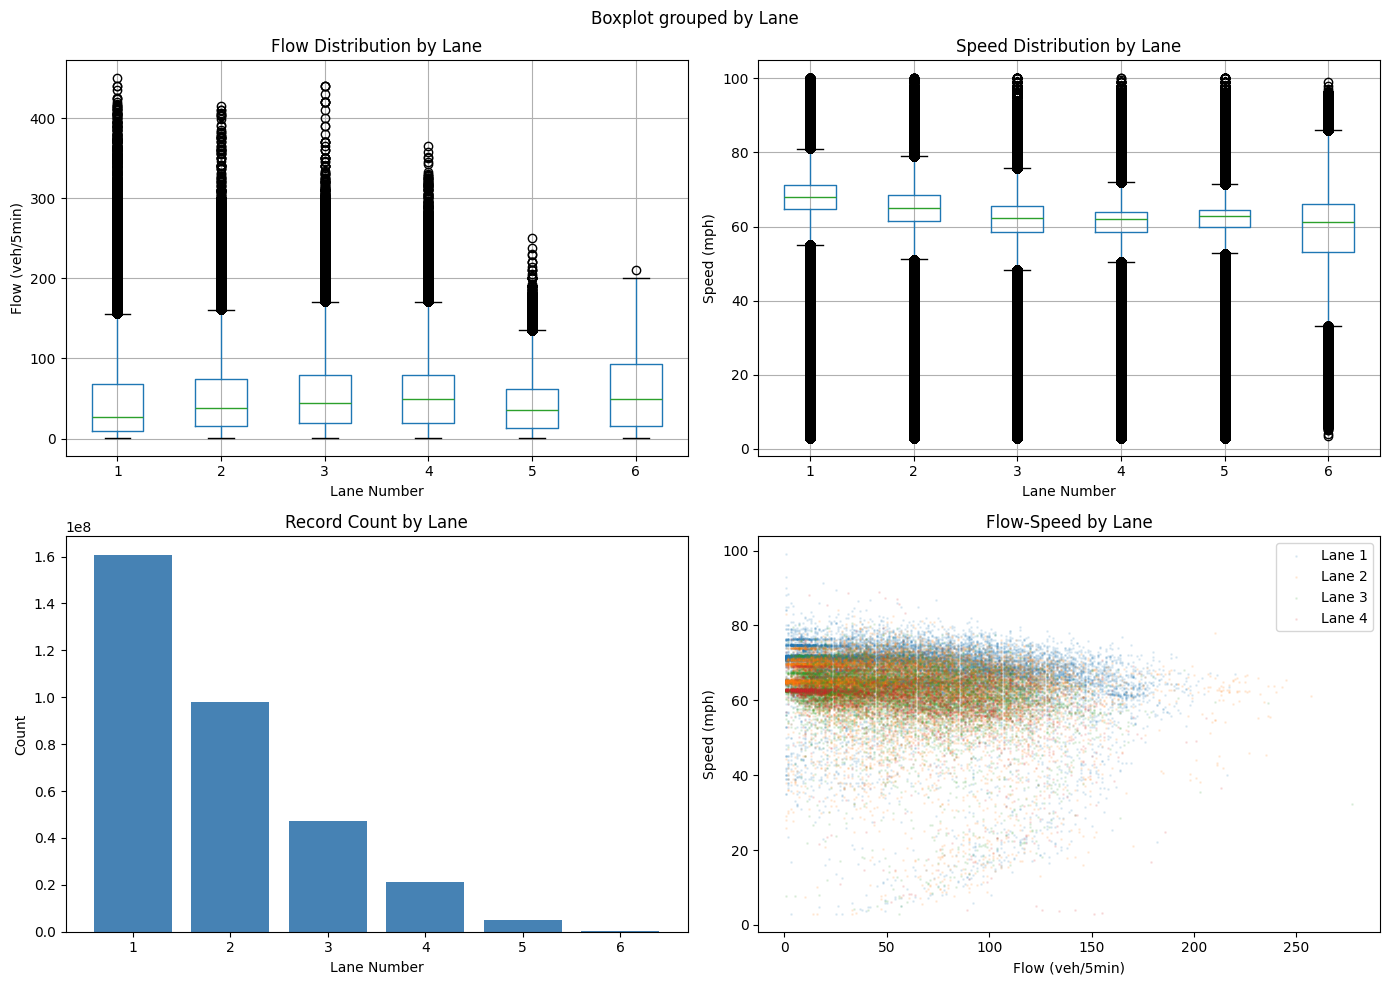

图表已保存: ../output/lane_level/lane_level_analysis.png


In [14]:
import matplotlib.pyplot as plt

if 'lane_df' in dir():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 各车道流量分布
    lane_df.boxplot(column='Lane_Flow', by='Lane', ax=axes[0, 0])
    axes[0, 0].set_title('Flow Distribution by Lane')
    axes[0, 0].set_xlabel('Lane Number')
    axes[0, 0].set_ylabel('Flow (veh/5min)')
    plt.suptitle('')  # 移除自动标题
    
    # 2. 各车道速度分布
    lane_df.boxplot(column='Lane_Speed', by='Lane', ax=axes[0, 1])
    axes[0, 1].set_title('Speed Distribution by Lane')
    axes[0, 1].set_xlabel('Lane Number')
    axes[0, 1].set_ylabel('Speed (mph)')
    
    # 3. 各车道数据量
    lane_counts = lane_df['Lane'].value_counts().sort_index()
    axes[1, 0].bar(lane_counts.index, lane_counts.values, color='steelblue')
    axes[1, 0].set_title('Record Count by Lane')
    axes[1, 0].set_xlabel('Lane Number')
    axes[1, 0].set_ylabel('Count')
    
    # 4. 车道流量-速度关系
    sample = lane_df.dropna(subset=['Lane_Flow', 'Lane_Speed']).sample(min(50000, len(lane_df)))
    for lane in sorted(sample['Lane'].unique())[:4]:  # 只显示前4车道
        lane_data = sample[sample['Lane'] == lane]
        axes[1, 1].scatter(lane_data['Lane_Flow'], lane_data['Lane_Speed'], 
                           alpha=0.1, s=1, label=f'Lane {lane}')
    axes[1, 1].set_title('Flow-Speed by Lane')
    axes[1, 1].set_xlabel('Flow (veh/5min)')
    axes[1, 1].set_ylabel('Speed (mph)')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'lane_level_analysis.png'), dpi=150)
    plt.show()
    print(f"图表已保存: {OUTPUT_DIR}/lane_level_analysis.png")

## 2.7 保存处理后的数据

In [15]:
# 保存各时间段的同位置传感器信息
if 'period_info' in dir():
    all_colocated = []
    for meta_date, colocated_df in period_info.items():
        if len(colocated_df) > 0:
            colocated_df = colocated_df.copy()
            colocated_df['Meta_Date'] = meta_date
            all_colocated.append(colocated_df)
    
    if all_colocated:
        all_colocated_df = pd.concat(all_colocated, ignore_index=True)
        output_path = os.path.join(OUTPUT_DIR, 'colocated_sensors_by_period.csv')
        all_colocated_df.to_csv(output_path, index=False)
        print(f"已保存: {output_path}")

# 保存映射变化记录
if 'mapping_changes_df' in dir() and mapping_changes_df is not None and len(mapping_changes_df) > 0:
    output_path = os.path.join(OUTPUT_DIR, 'colocated_mapping_changes.csv')
    mapping_changes_df.to_csv(output_path, index=False)
    print(f"已保存: {output_path}")

# 保存合并后的车道数据
if 'lane_df_merged' in dir():
    output_path = os.path.join(OUTPUT_DIR, 'pems_5min_lane_level_merged.parquet')
    lane_df_merged.to_parquet(output_path, index=False)
    print(f"已保存: {output_path}")
    print(f"大小: {os.path.getsize(output_path)/1024/1024:.2f} MB")

已保存: ../output/lane_level/colocated_sensors_by_period.csv
已保存: ../output/lane_level/colocated_mapping_changes.csv
已保存: ../output/lane_level/pems_5min_lane_level_merged.parquet
大小: 3459.25 MB


---
## 输出文件说明

| 文件 | 格式 | 说明 |
|------|------|------|
| `pems_5min_station_level.parquet` | 站点级 | 总流量、平均速度、平均占有率 |
| `pems_5min_lane_level.parquet` | 车道级 | 每车道的流量、速度、占有率 |
| `pems_5min_lane_level_merged.parquet` | 车道级(动态合并) | 基于时间点元数据合并的车道数据 |
| `colocated_sensors_by_period.csv` | 元数据 | 各时间段的同位置传感器组 |
| `colocated_mapping_changes.csv` | 元数据 | 同位置传感器映射的变化记录 |

## 动态合并逻辑

```
数据记录时间戳: 2025-03-15 08:00:00
        ↓
查找 <= 2025-03-15 的最新元数据
        ↓
使用该元数据检测同位置传感器
        ↓
应用对应的合并映射
```

## 为什么需要动态合并？

1. **传感器新增/移除**：某个时间点后，HOV传感器可能被添加或移除
2. **元数据修正**：Abs_PM、Lanes 等字段可能被修正
3. **位置变化**：传感器可能被重新标定位置

使用静态元数据会导致：
- 历史数据被错误合并（该传感器当时不存在）
- 当前数据合并遗漏（新增的同位置传感器）